In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data if not already present
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Load data (adjust file path as needed)
df = pd.read_csv('/kaggle/input/datasets/saurabhshahane/fake-news-classification/WELFake_Dataset.csv')  # or the correct file name

# ============================================================================
# 1. Basic info & missing values
# ============================================================================
print("=== Basic Information ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

# Drop rows where essential text is missing
df.dropna(subset=['text'], inplace=True)
df.dropna(subset=['title'], inplace=True)   # title optional, but keep for analysis


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


=== Basic Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB
None

=== Missing Values ===
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


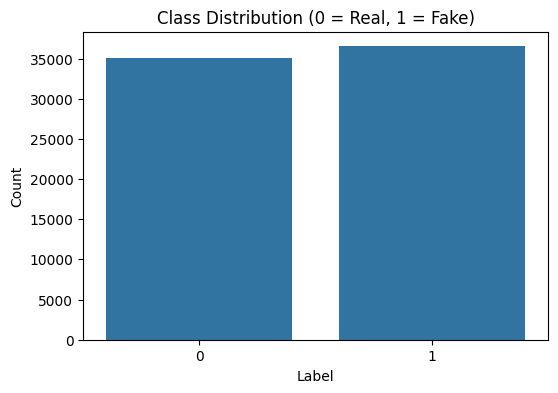


=== Class Counts ===
label
1    36509
0    35028
Name: count, dtype: int64


In [3]:
# 2. Class Distribution (Imbalance)
# ============================================================================
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Class Distribution (0 = Real, 1 = Fake)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

print("\n=== Class Counts ===")
print(df['label'].value_counts())

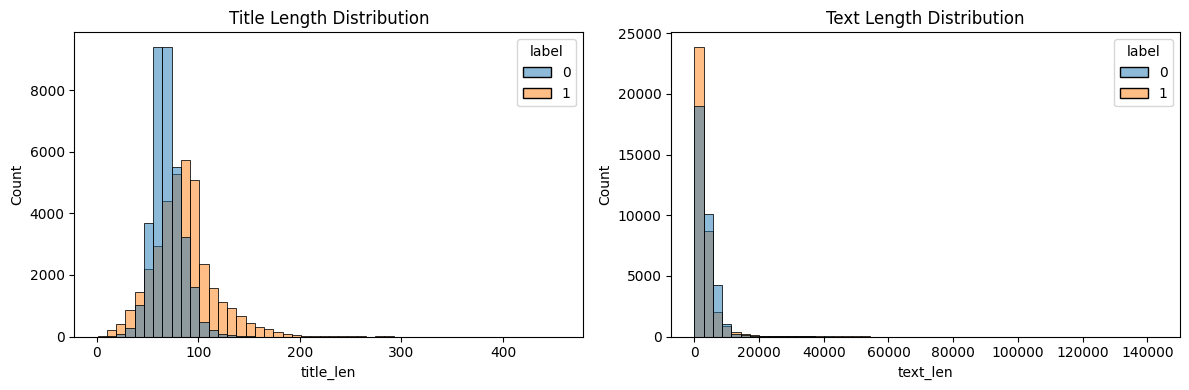

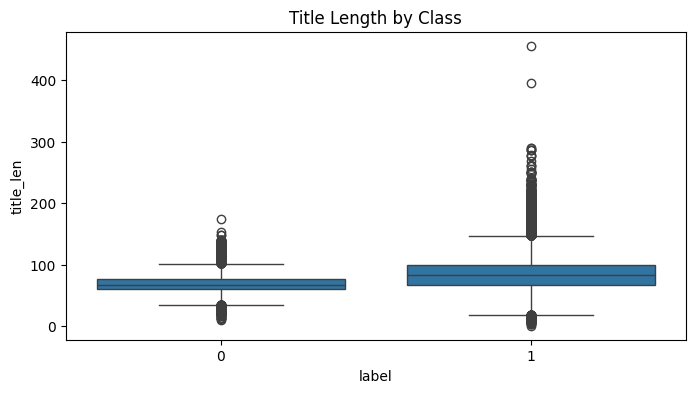

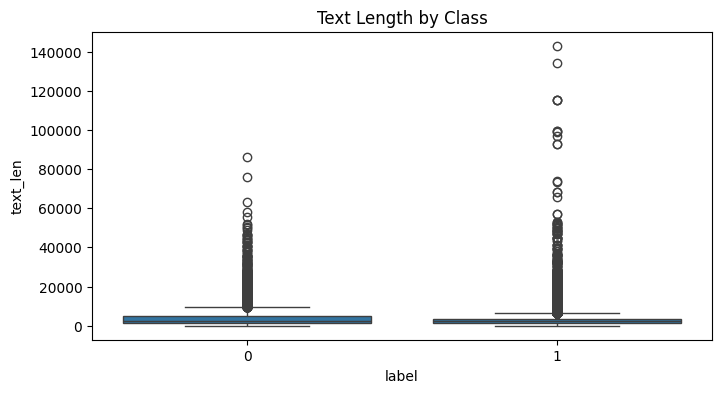

In [4]:
# ============================================================================
# 3. Text Length Analysis
# ============================================================================
df['title_len'] = df['title'].astype(str).apply(len)
df['text_len'] = df['text'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df, x='title_len', hue='label', bins=50, ax=axes[0])
axes[0].set_title('Title Length Distribution')
sns.histplot(df, x='text_len', hue='label', bins=50, ax=axes[1])
axes[1].set_title('Text Length Distribution')
plt.tight_layout()
plt.show()

# Boxplots to compare lengths by class
plt.figure(figsize=(8,4))
sns.boxplot(x='label', y='title_len', data=df)
plt.title('Title Length by Class')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='label', y='text_len', data=df)
plt.title('Text Length by Class')
plt.show()


In [5]:
# ============================================================================
# 4. Text Preprocessing for Word Frequency
# ============================================================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Basic cleaning: lowercase, remove punctuation, numbers, stopwords"""
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]          # keep only alphabetic
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

# Clean title and text (separately)
df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)

# Combine title and text for overall word frequency
df['all_text'] = df['clean_title'] + df['clean_text']

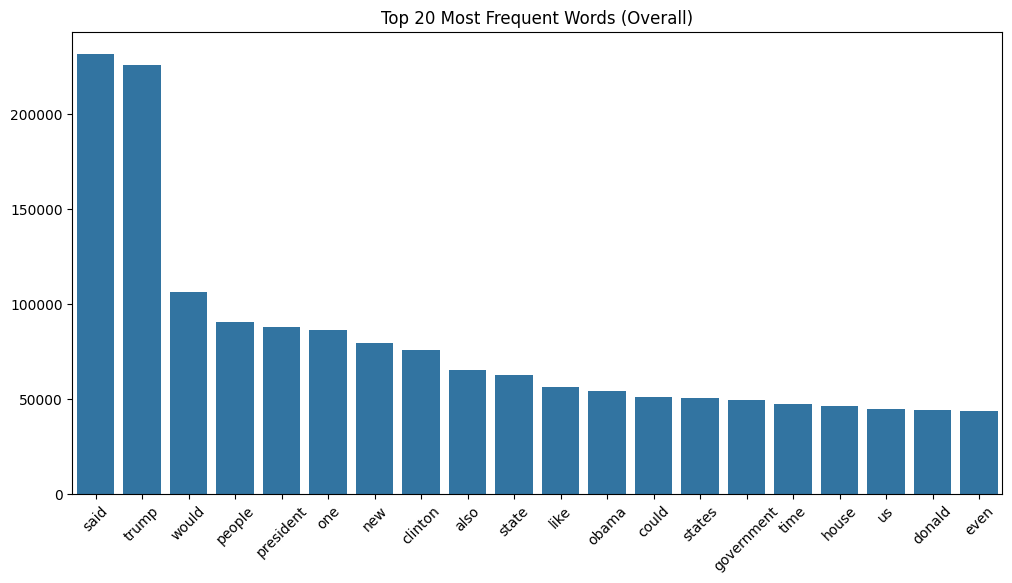

In [6]:
# ============================================================================
# 5. Most Frequent Words (Overall)
# ============================================================================
all_words = [word for tokens in df['all_text'] for word in tokens]
freq_dist = FreqDist(all_words)
common_words = freq_dist.most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(12,6))
sns.barplot(x=list(words), y=list(counts))
plt.title('Top 20 Most Frequent Words (Overall)')
plt.xticks(rotation=45)
plt.show()


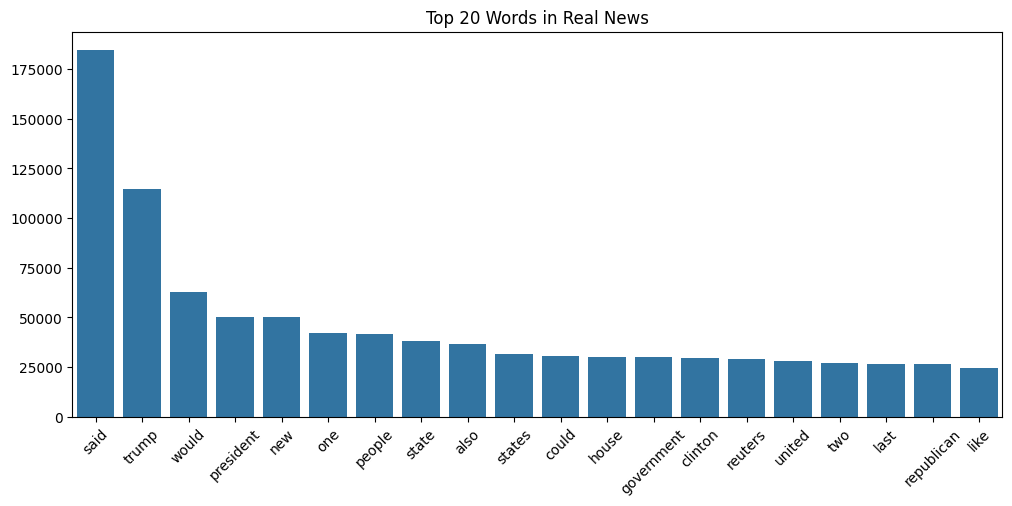

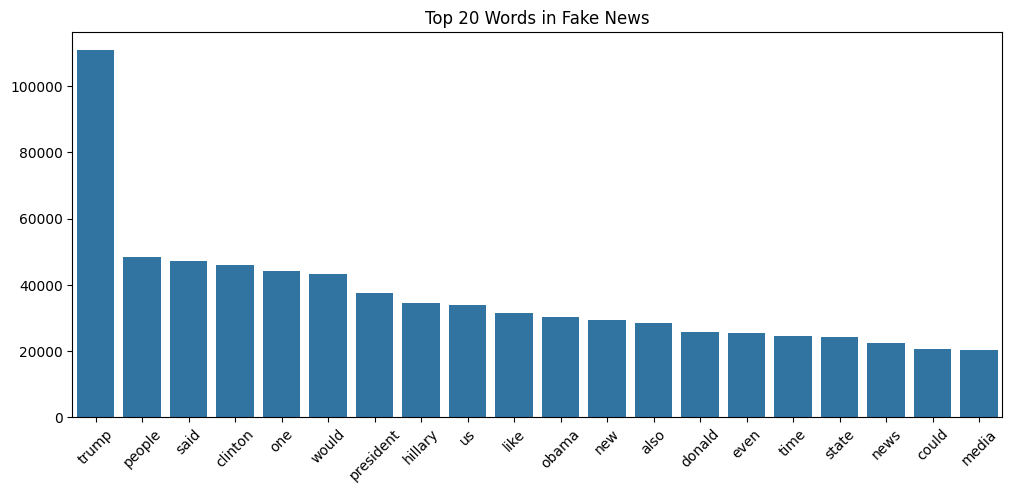

In [7]:
# ============================================================================
# 6. Most Frequent Words by Class
# ============================================================================
def plot_top_words(df, label_val, title, n=20):
    class_words = [word for tokens in df[df['label']==label_val]['all_text'] for word in tokens]
    freq = FreqDist(class_words)
    common = freq.most_common(n)
    words, counts = zip(*common)
    plt.figure(figsize=(12,5))
    sns.barplot(x=list(words), y=list(counts))
    plt.title(f'Top {n} Words in {title} News')
    plt.xticks(rotation=45)
    plt.show()

plot_top_words(df, 0, 'Real', n=20)
plot_top_words(df, 1, 'Fake', n=20)


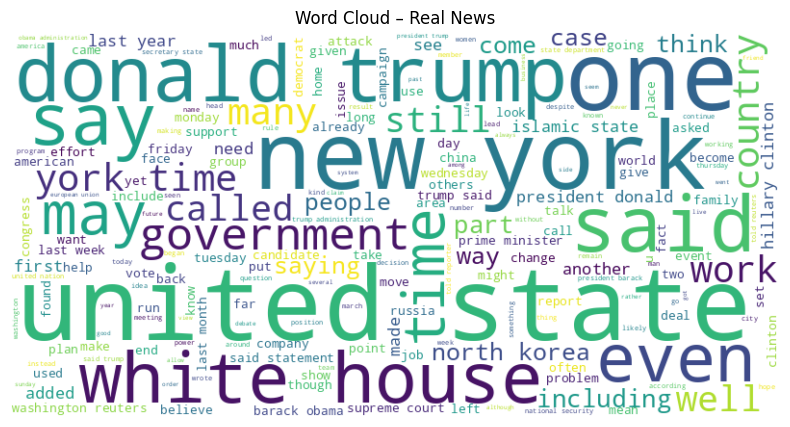

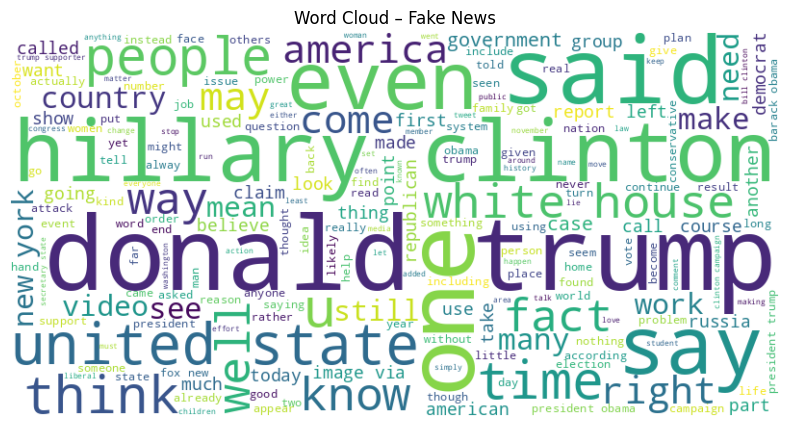

In [8]:
# ============================================================================
# 7. Word Clouds
# ============================================================================
def generate_wordcloud(df, label, title):
    text = ' '.join([' '.join(tokens) for tokens in df[df['label']==label]['all_text']])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

generate_wordcloud(df, 0, 'Word Cloud – Real News')
generate_wordcloud(df, 1, 'Word Cloud – Fake News')

In [9]:
# ============================================================================
# 8. N-grams Analysis (Bigrams)
# ============================================================================
from nltk.util import ngrams
from collections import Counter

def get_ngrams(texts, n=2, top=20):
    all_ngrams = []
    for tokens in texts:
        ngrams_list = list(ngrams(tokens, n))
        all_ngrams.extend(ngrams_list)
    return Counter(all_ngrams).most_common(top)

real_texts = df[df['label']==0]['all_text']
fake_texts = df[df['label']==1]['all_text']

print("Top 10 Bigrams in Real News:")
for gram, count in get_ngrams(real_texts, n=2, top=10):
    print(f"{' '.join(gram)}: {count}")

print("\nTop 10 Bigrams in Fake News:")
for gram, count in get_ngrams(fake_texts, n=2, top=10):
    print(f"{' '.join(gram)}: {count}")

Top 10 Bigrams in Real News:
united states: 22165
new york: 18984
donald trump: 17720
white house: 14909
york times: 9129
north korea: 7401
president donald: 7118
last year: 6709
hillary clinton: 6544
washington reuters: 6492

Top 10 Bigrams in Fake News:
donald trump: 23138
hillary clinton: 16792
united states: 11544
white house: 9580
new york: 6999
image via: 6429
president obama: 5114
president trump: 4522
fox news: 4241
barack obama: 3502


In [10]:
# ============================================================================
# 9. Duplicate Detection
# ============================================================================
# Check exact duplicates in title + text
duplicate_rows = df.duplicated(subset=['title', 'text'])
print(f"\nNumber of duplicate rows (exact title+text): {duplicate_rows.sum()}")

# Check near duplicates by text length or cosine similarity (advanced)
# Simple: show rows with identical titles
dup_titles = df['title'].duplicated(keep=False)
print(f"Number of rows with duplicate titles: {dup_titles.sum()}")
if dup_titles.sum() > 0:
    print(df[dup_titles][['title', 'label']].head())



Number of duplicate rows (exact title+text): 8416
Number of rows with duplicate titles: 17578
                                                title  label
4   SATAN 2: Russia unvelis an image of its terrif...      1
5   About Time! Christian Group Sues Amazon and SP...      1
7   HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...      1
8   Sports Bar Owner Bans NFL Games…Will Show Only...      1
13  WATCH: HILARIOUS AD Calls Into Question Health...      1


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


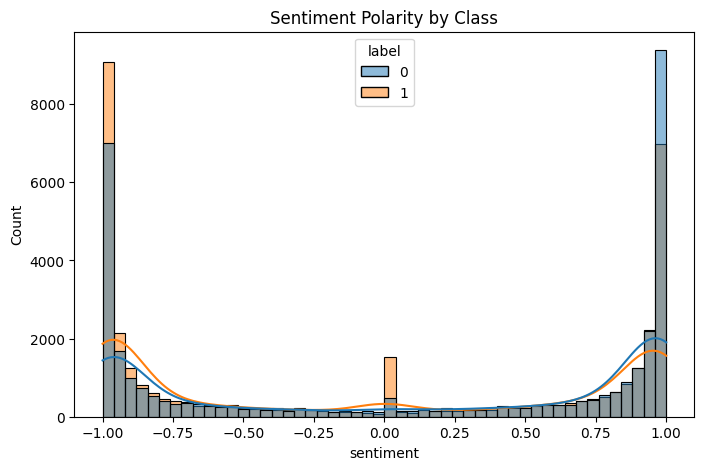

In [11]:
# ============================================================================
# 10. Basic Sentiment Analysis (Optional)
# ============================================================================
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

df['sentiment'] = df['text'].astype(str).apply(get_sentiment)

plt.figure(figsize=(8,5))
sns.histplot(df, x='sentiment', hue='label', bins=50, kde=True)
plt.title('Sentiment Polarity by Class')
plt.show()

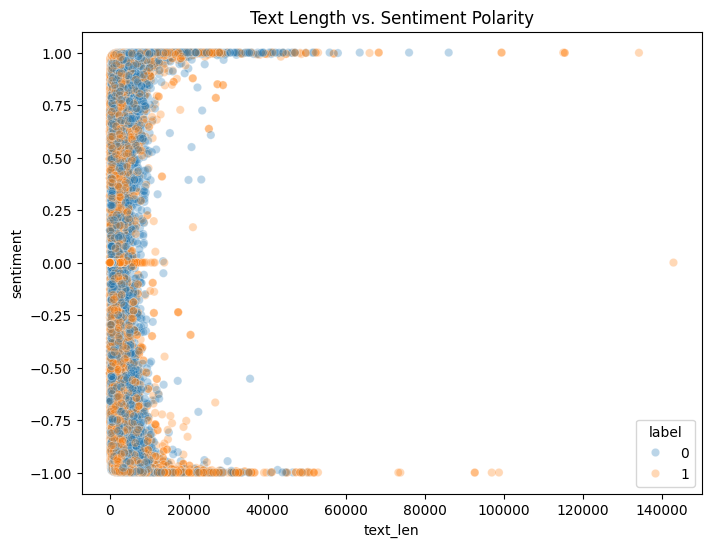

In [12]:
# ============================================================================
# 11. Correlation: Length vs. Sentiment
# ============================================================================
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='text_len', y='sentiment', hue='label', alpha=0.3)
plt.title('Text Length vs. Sentiment Polarity')
plt.show()


In [13]:

# ============================================================================



# ============================================================================
# 12. Summary Statistics
# ============================================================================
print("\n=== Summary Statistics ===")
print(df[['title_len', 'text_len', 'sentiment']].describe(percentiles=[.1, .25, .5, .75, .9]))

print("\n=== By Class ===")
print(df.groupby('label')[['title_len', 'text_len', 'sentiment']].mean())


=== Summary Statistics ===
          title_len       text_len     sentiment
count  71537.000000   71537.000000  71537.000000
mean      77.130240    3292.722116      0.027312
std       25.028377    3738.194002      0.854893
min        1.000000       1.000000     -1.000000
10%       52.000000     551.000000     -0.992440
25%       62.000000    1410.000000     -0.945200
50%       73.000000    2440.000000      0.077200
75%       89.000000    4077.000000      0.949300
90%      106.000000    6671.400000      0.991900
max      456.000000  142961.000000      1.000000

=== By Class ===
       title_len    text_len  sentiment
label                                  
0      68.790596  3495.31669   0.105209
1      85.131584  3098.34586  -0.047425
